---
## Cellule 1 : Importation des Librairies et du Dataset

In [1]:
# --- Librairies standard ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# --- Librairies scikit-learn pour preprocessing et modeles classiques ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
from sklearn.model_selection import train_test_split

# --- TensorFlow / Keras pour les modeles de deep learning ---
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, RepeatVector,
    TimeDistributed, Conv1D, GlobalMaxPooling1D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
histories = {}
training_times = {}
results = {}

# Fixer la graine aleatoire pour la reproductibilite des resultats
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('Numpy version:', np.__version__)
print('Pandas version:', pd.__version__)

# --- Noms des colonnes du dataset C-MAPSS ---
# Le dataset ne contient pas d'en-tete, on les definit manuellement
COLUMN_NAMES = [
    'unit_nr', 'time_cycles',
    'setting_1', 'setting_2', 'setting_3',
    's_1', 's_2', 's_3', 's_4', 's_5',
    's_6', 's_7', 's_8', 's_9', 's_10',
    's_11', 's_12', 's_13', 's_14', 's_15',
    's_16', 's_17', 's_18', 's_19', 's_20', 's_21'
]

# --- Chargement des trois fichiers du dataset FD001 ---
# train_FD001 : historique complet jusqu'a la panne pour chaque moteur
# test_FD001  : historique partiel (la panne n'est pas incluse)
# RUL_FD001   : Remaining Useful Life reelle pour chaque moteur du jeu de test
train_df = pd.read_csv('train_FD001.csv', header=0, names=COLUMN_NAMES)
test_df  = pd.read_csv('test_FD001.csv',  header=0, names=COLUMN_NAMES)
rul_df   = pd.read_csv('RUL_FD001.csv',   header=0, names=['RUL'])

print('\nFormes des donnees chargees :')
print(f'  Train : {train_df.shape[0]} lignes x {train_df.shape[1]} colonnes')
print(f'  Test  : {test_df.shape[0]}  lignes x {test_df.shape[1]} colonnes')
print(f'  RUL   : {rul_df.shape[0]} moteurs de reference')

TensorFlow version: 2.20.0
Numpy version: 2.0.2
Pandas version: 2.2.2

Formes des donnees chargees :
  Train : 20631 lignes x 26 colonnes
  Test  : 13096  lignes x 26 colonnes
  RUL   : 100 moteurs de reference


---
## Cellule 2 : Exploration des Donnees (EDA)

In [2]:
# --- Apercu general du dataset d'entrainement ---
print('=== Apercu des premieres lignes ===')
display(train_df.head(10))

print('\n=== Statistiques descriptives ===')
display(train_df.describe().round(3))

print('\n=== Valeurs manquantes par colonne ===')
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Aucune valeur manquante.')

# Nombre de moteurs uniques dans chaque jeu
n_train_units = train_df['unit_nr'].nunique()
n_test_units  = test_df['unit_nr'].nunique()
print(f'\nNombre de moteurs en train : {n_train_units}')
print(f'Nombre de moteurs en test  : {n_test_units}')

=== Apercu des premieres lignes ===


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694



=== Statistiques descriptives ===


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
count,20631.000,20631.000,20631.000,20631.000,20631.0,20631.00,20631.000,20631.000,20631.000,20631.00,...,20631.000,20631.000,20631.000,20631.000,20631.00,20631.000,20631.0,20631.0,20631.000,20631.000
mean,51.507,108.808,-0.000,0.000,100.0,518.67,642.681,1590.523,1408.934,14.62,...,521.413,2388.096,8143.753,8.442,0.03,393.211,2388.0,100.0,38.816,23.290
std,29.228,68.881,0.002,0.000,0.0,0.00,0.500,6.131,9.001,0.00,...,0.738,0.072,19.076,0.038,0.00,1.549,0.0,0.0,0.181,0.108
min,1.000,1.000,-0.009,-0.001,100.0,518.67,641.210,1571.040,1382.250,14.62,...,518.690,2387.880,8099.940,8.325,0.03,388.000,2388.0,100.0,38.140,22.894
25%,26.000,52.000,-0.002,-0.000,100.0,518.67,642.325,1586.260,1402.360,14.62,...,520.960,2388.040,8133.245,8.415,0.03,392.000,2388.0,100.0,38.700,23.222
50%,52.000,104.000,0.000,0.000,100.0,518.67,642.640,1590.100,1408.040,14.62,...,521.480,2388.090,8140.540,8.439,0.03,393.000,2388.0,100.0,38.830,23.298
75%,77.000,156.000,0.002,0.000,100.0,518.67,643.000,1594.380,1414.555,14.62,...,521.950,2388.140,8148.310,8.466,0.03,394.000,2388.0,100.0,38.950,23.367
max,100.000,362.000,0.009,0.001,100.0,518.67,644.530,1616.910,1441.490,14.62,...,523.380,2388.560,8293.720,8.585,0.03,400.000,2388.0,100.0,39.430,23.618



=== Valeurs manquantes par colonne ===
Aucune valeur manquante.

Nombre de moteurs en train : 100
Nombre de moteurs en test  : 100


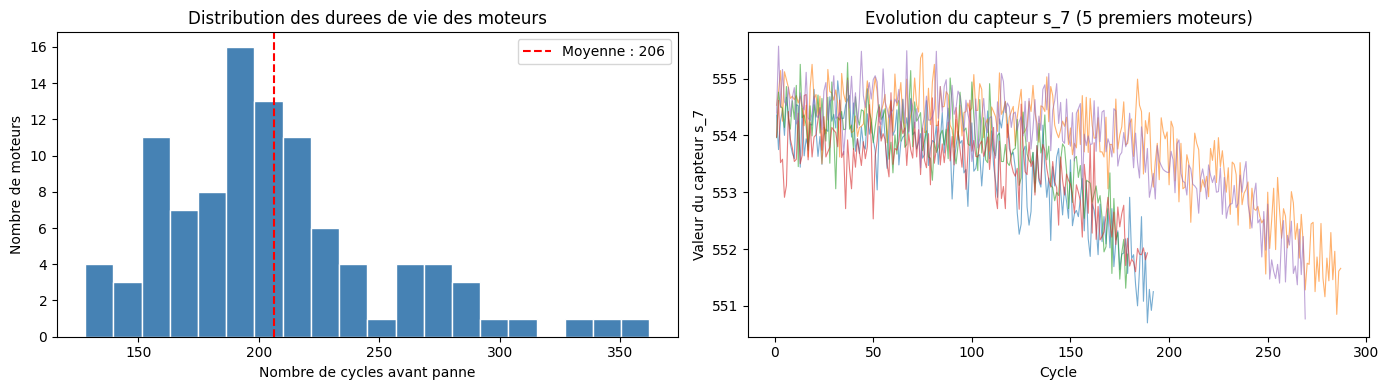

Duree de vie moyenne : 206.3 cycles
Duree de vie min/max : 128 / 362 cycles


In [3]:

# --- Distribution du nombre de cycles par moteur (duree de vie) ---
# Cette analyse revele la variabilite des durees de vie entre moteurs
cycles_per_unit = train_df.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme des durees de vie
axes[0].hist(cycles_per_unit, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des durees de vie des moteurs')
axes[0].set_xlabel('Nombre de cycles avant panne')
axes[0].set_ylabel('Nombre de moteurs')
axes[0].axvline(cycles_per_unit.mean(), color='red', linestyle='--', label=f'Moyenne : {cycles_per_unit.mean():.0f}')
axes[0].legend()

# Evolution d'un capteur representatif (s_7) pour quelques moteurs
# s_7 est connu pour montrer une degradation claire dans FD001
for unit_id in [1, 2, 3, 4, 5]:
    unit_data = train_df[train_df['unit_nr'] == unit_id]
    axes[1].plot(unit_data['time_cycles'], unit_data['s_7'], alpha=0.6, linewidth=0.8)
axes[1].set_title('Evolution du capteur s_7 (5 premiers moteurs)')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Valeur du capteur s_7')

plt.tight_layout()
plt.show()

print(f'Duree de vie moyenne : {cycles_per_unit.mean():.1f} cycles')
print(f'Duree de vie min/max : {cycles_per_unit.min()} / {cycles_per_unit.max()} cycles')

Capteurs inutiles (variance < 0.01) : ['s_1', 's_5', 's_6', 's_8', 's_10', 's_13', 's_15', 's_16', 's_18', 's_19']
Capteurs utiles retenus : ['s_2', 's_3', 's_4', 's_7', 's_9', 's_11', 's_12', 's_14', 's_17', 's_20', 's_21']


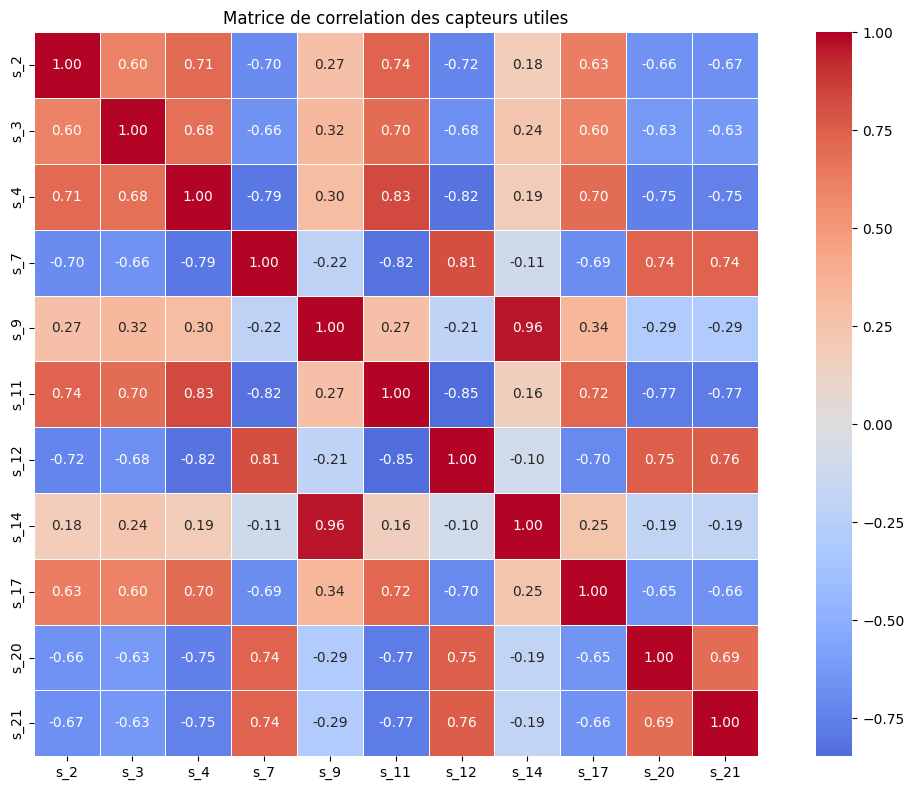

In [4]:
# --- Identification des capteurs avec variance nulle ---
# Certains capteurs sont constants dans FD001 et n'apportent aucune information
# Les conserver entrainerait du bruit inutile dans les modeles
sensor_cols = [c for c in COLUMN_NAMES if c.startswith('s_')]
variance = train_df[sensor_cols].var()

# Capteurs a variance quasi nulle (seuil = 0.01)
USELESS_SENSORS = variance[variance < 0.01].index.tolist()
USEFUL_SENSORS  = variance[variance >= 0.01].index.tolist()

print('Capteurs inutiles (variance < 0.01) :', USELESS_SENSORS)
print('Capteurs utiles retenus :', USEFUL_SENSORS)

# --- Matrice de correlation entre capteurs utiles ---
plt.figure(figsize=(12, 8))
corr_matrix = train_df[USEFUL_SENSORS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matrice de correlation des capteurs utiles')
plt.tight_layout()
plt.show()

---
## Cellule 3 : Preprocessing, Etiquetage et Normalisation

Distribution des etiquettes d'anomalie dans le train :
anomaly
0    17531
1     3100
Name: count, dtype: int64
Pourcentage de cycles anomaux : 15.0%


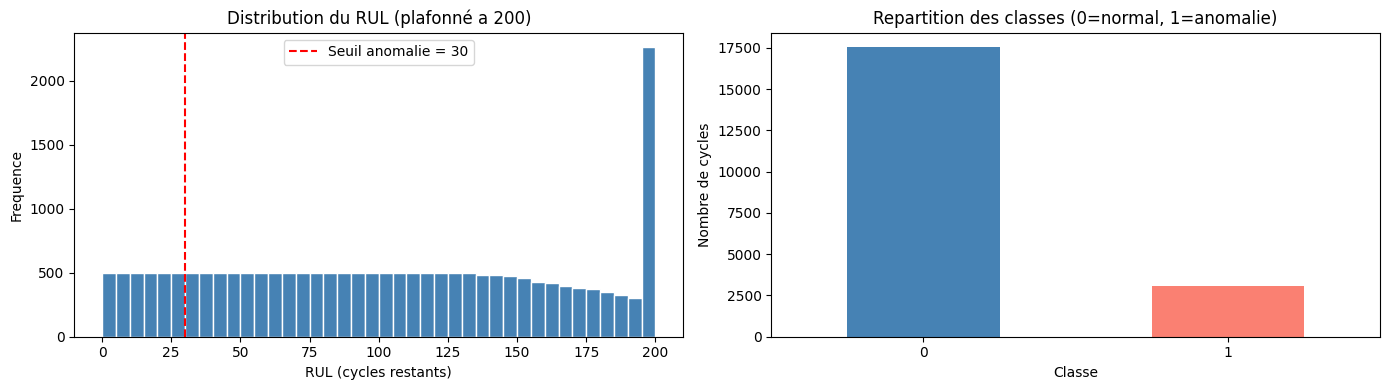

In [5]:
# --- Calcul du RUL (Remaining Useful Life) pour chaque ligne du train ---
# Le RUL d'une ligne = (dernier cycle du moteur) - (cycle actuel)
# Cela permet de savoir a chaque instant combien de cycles il reste avant la panne

def add_rul(df):
    """Ajoute une colonne RUL calculee a partir du cycle maximal de chaque moteur."""
    max_cycles = df.groupby('unit_nr')['time_cycles'].max().reset_index()
    max_cycles.columns = ['unit_nr', 'max_cycle']
    df = df.merge(max_cycles, on='unit_nr')
    df['RUL'] = df['max_cycle'] - df['time_cycles']
    df.drop(columns=['max_cycle'], inplace=True)
    return df

train_df = add_rul(train_df)

# --- Creation de l'etiquette binaire d'anomalie ---
# Un cycle est considere "anormal" (proche de la panne) si RUL <= seuil
# Ce seuil de 30 cycles est classique dans la litterature sur C-MAPSS
ANOMALY_THRESHOLD = 30

train_df['anomaly'] = (train_df['RUL'] <= ANOMALY_THRESHOLD).astype(int)

print('Distribution des etiquettes d\'anomalie dans le train :')
print(train_df['anomaly'].value_counts())
print(f'Pourcentage de cycles anomaux : {train_df["anomaly"].mean()*100:.1f}%')

# --- Visualisation de la distribution RUL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_df['RUL'].clip(upper=200), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(ANOMALY_THRESHOLD, color='red', linestyle='--',
                label=f'Seuil anomalie = {ANOMALY_THRESHOLD}')
axes[0].set_title('Distribution du RUL (plafonné a 200)')
axes[0].set_xlabel('RUL (cycles restants)')
axes[0].set_ylabel('Frequence')
axes[0].legend()

train_df['anomaly'].value_counts().plot.bar(ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Repartition des classes (0=normal, 1=anomalie)')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre de cycles')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

In [6]:
# --- Colonnes de features retenues pour l'entrainement ---
# On garde uniquement les capteurs utiles + les settings
# On exclut unit_nr, time_cycles, RUL et anomaly (cibles, pas features)
SETTING_COLS  = ['setting_1', 'setting_2', 'setting_3']
FEATURE_COLS  = SETTING_COLS + USEFUL_SENSORS

print(f'Features retenues ({len(FEATURE_COLS)}) :', FEATURE_COLS)

# --- Normalisation MinMax sur [0, 1] ---
# IMPORTANT : le scaler est ENTRAINE UNIQUEMENT sur le train
# et applique ensuite au test sans re-entrainement.
# Entrainer le scaler sur le test ou sur l'ensemble complet serait du data leakage.
scaler = MinMaxScaler()
train_df[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])

# Application du meme scaler (fit sur train) au jeu de test
test_df[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])

print('\nNormalisation terminee. Verification des bornes sur le train :')
print(train_df[FEATURE_COLS].min().describe())
print(train_df[FEATURE_COLS].max().describe())

Features retenues (14) : ['setting_1', 'setting_2', 'setting_3', 's_2', 's_3', 's_4', 's_7', 's_9', 's_11', 's_12', 's_14', 's_17', 's_20', 's_21']

Normalisation terminee. Verification des bornes sur le train :
count    14.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64
count    14.000000
mean      0.928571
std       0.267261
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000
dtype: float64


---
## Cellule 4 : Construction des Sequences Temporelles (Sliding Window)

In [7]:
# --- Parametres de la fenetre glissante ---
# Chaque sequence couvre SEQ_LEN cycles consecutifs du meme moteur.
# L'etiquette de la sequence est celle du dernier cycle de la fenetre.
# Ce principe evite le data leakage entre moteurs car on ne melange
# jamais des cycles appartenant a des moteurs differents.
SEQ_LEN = 30  # longueur de la fenetre (nombre de cycles par sequence)

def create_sequences(df, seq_len, feature_cols, label_col=None):
    """
    Construit des sequences de longueur seq_len par fenetre glissante.
    Chaque moteur (unit_nr) est traite independamment pour eviter
    de melanger des cycles appartenant a des moteurs differents.

    Retourne:
        X : tableau de forme (n_sequences, seq_len, n_features)
        y : tableau de forme (n_sequences,) si label_col fourni, sinon None
    """
    X_list, y_list = [], []

    for unit_id in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit_id].sort_values('time_cycles')
        features  = unit_data[feature_cols].values
        labels    = unit_data[label_col].values if label_col else None

        n_cycles = len(features)

        # On cree une sequence pour chaque position possible dans le moteur
        for i in range(n_cycles - seq_len + 1):
            X_list.append(features[i : i + seq_len])
            if labels is not None:
                # L'etiquette correspond au dernier cycle de la fenetre
                y_list.append(labels[i + seq_len - 1])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y


def create_test_sequences(df, seq_len, feature_cols):
    """
    Pour le jeu de test, on prend uniquement la DERNIERE sequence de chaque moteur.
    Cela represente l'etat courant du moteur au moment de l'evaluation.
    """
    X_list = []
    for unit_id in sorted(df['unit_nr'].unique()):
        unit_data = df[df['unit_nr'] == unit_id].sort_values('time_cycles')
        features  = unit_data[feature_cols].values
        n_cycles  = len(features)

        if n_cycles >= seq_len:
            # On prend les seq_len derniers cycles
            X_list.append(features[-seq_len:])
        else:
            # Si le moteur a moins de seq_len cycles, on pad avec des zeros au debut
            pad = np.zeros((seq_len - n_cycles, len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, features]))

    return np.array(X_list, dtype=np.float32)


# --- Construction des sequences d'entrainement ---
X_all, y_all = create_sequences(train_df, SEQ_LEN, FEATURE_COLS, label_col='anomaly')
print(f'Sequences construites : X={X_all.shape}, y={y_all.shape}')
print(f'Pourcentage de sequences anomales : {y_all.mean()*100:.1f}%')

# --- Division train / validation en respectant les moteurs ---
# IMPORTANT : on divise par moteur et non par cycle individuel.
# Diviser par cycle individuel ferait fuir l'information du futur
# vers le passe (data leakage temporel). En separant les moteurs entiers,
# on garantit que le modele ne voit jamais de donnees du moteur de validation.
all_units = train_df['unit_nr'].unique()
train_units, val_units = train_test_split(all_units, test_size=0.2, random_state=SEED)

# Masques pour selectionner les sequences appartenant a chaque split
# On remet en index les unit_nr associes a chaque sequence
unit_labels = []
for unit_id in train_df['unit_nr'].unique():
    unit_data = train_df[train_df['unit_nr'] == unit_id]
    n_cycles  = len(unit_data)
    n_seq     = max(0, n_cycles - SEQ_LEN + 1)
    unit_labels.extend([unit_id] * n_seq)
unit_labels = np.array(unit_labels)

train_mask = np.isin(unit_labels, train_units)
val_mask   = np.isin(unit_labels, val_units)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]

# --- Sequences pour le jeu de test ---
X_test = create_test_sequences(test_df, SEQ_LEN, FEATURE_COLS)

# Etiquettes de test : anomalie si RUL_reelle <= seuil
y_test = (rul_df['RUL'].values <= ANOMALY_THRESHOLD).astype(int)

print(f'\nTailles des splits :')
print(f'  X_train : {X_train.shape}, y_train : {y_train.shape}')
print(f'  X_val   : {X_val.shape},   y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape},  y_test  : {y_test.shape}')

Sequences construites : X=(17731, 30, 14), y=(17731,)
Pourcentage de sequences anomales : 17.5%

Tailles des splits :
  X_train : (14241, 30, 14), y_train : (14241,)
  X_val   : (3490, 30, 14),   y_val   : (3490,)
  X_test  : (100, 30, 14),  y_test  : (100,)


---
## Cellule 5 : Entrainement des Modeles

### Modeles choisis et justifications :
- **LSTM supervisé** : capture les dependances temporelles longues dans les sequences de capteurs
- **CNN 1D** : extrait des patterns locaux dans les signaux, tres rapide et efficace
- **TCN** : convolutions causales dilatees avec connexions residuelles, grand champ recepteur
- **Transformer Encoder** : mecanisme d'auto-attention multi-tete, capture les dependances globales
- **GRU + Attention** : GRU bicouche avec attention temporelle pour ponderer les instants cles

**Anti-surapprentissage :** Dropout, BatchNormalization, EarlyStopping sur validation  
**Anti-data leakage :** Scaler entraine sur train uniquement, separation par moteur entier


In [8]:
# --- Dictionnaire pour stocker les resultats de tous les modeles ---
# Ce dictionnaire sera rempli au fur et a mesure et utilise
# dans la cellule de comparaison finale
results = {}


# --- Chronometre : mesurer le temps d'entrainement de chaque modele ---
import time
training_times = {}

# --- Dossier pour sauvegarder les modeles entraines ---
import os
os.makedirs('saved_models', exist_ok=True)
print("Dossier 'saved_models/' cree.")

# --- Callbacks communs pour tous les modeles de deep learning ---
# EarlyStopping : arrete l'entrainement si la validation ne s'ameliore plus
# patience=10 signifie qu'on attend 10 epochs sans amelioration avant d'arreter
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)

# ReduceLROnPlateau : reduit le learning rate si la perte stagne
# cela permet de sortir des plateaux d'optimisation
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
)

N_FEATURES = len(FEATURE_COLS)  # nombre de capteurs en entree
print(f'Nombre de features : {N_FEATURES}')
print(f'Longueur des sequences : {SEQ_LEN}')

Dossier 'saved_models/' cree.
Nombre de features : 14
Longueur des sequences : 30


In [9]:
# ============================================================
# MODELE 1 : LSTM Supervise
# ============================================================
# Architecture : deux couches LSTM empilees avec Dropout pour la regularisation
# La premiere couche LSTM retourne les sequences completes (return_sequences=True)
# afin que la deuxieme couche puisse les traiter cycle par cycle.
# La couche Dense finale avec sigmoid produit une probabilite d'anomalie.

print('Construction du modele LSTM...')

def build_lstm_model(seq_len, n_features):
    """Construit un LSTM bicouche pour la classification binaire d'anomalie."""
    model = Sequential([
        # Premiere couche LSTM : 64 unites, retourne toute la sequence
        LSTM(64, input_shape=(seq_len, n_features),
             return_sequences=True, name='lstm_1'),
        # Dropout 20% pour eviter le surapprentissage
        Dropout(0.2, name='dropout_1'),

        # Deuxieme couche LSTM : 32 unites, retourne uniquement le dernier etat
        LSTM(32, return_sequences=False, name='lstm_2'),
        Dropout(0.2, name='dropout_2'),

        # Couche dense intermediaire avec regularisation BatchNorm
        Dense(16, activation='relu', name='dense_1'),
        BatchNormalization(name='batchnorm'),

        # Sortie binaire : probabilite d'etre une anomalie
        Dense(1, activation='sigmoid', name='output')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm_model(SEQ_LEN, N_FEATURES)
lstm_model.summary()


print('\nEntrainement du LSTM...')
_t0 = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
histories['LSTM'] = lstm_history

# Evaluation sur le jeu de test
lstm_probs  = lstm_model.predict(X_test, verbose=0).flatten()
lstm_preds  = (lstm_probs >= 0.5).astype(int)
lstm_auc    = roc_auc_score(y_test, lstm_probs)
lstm_f1     = f1_score(y_test, lstm_preds)
lstm_acc    = accuracy_score(y_test, lstm_preds)

# Stockage des resultats
results['LSTM'] = {
    'probs':    lstm_probs,
    'preds':    lstm_preds,
    'auc':      lstm_auc,
    'f1':       lstm_f1,
    'accuracy': lstm_acc,
    'history':  lstm_history
}

print(f'\nLSTM - AUC: {lstm_auc:.4f} | F1: {lstm_f1:.4f} | Accuracy: {lstm_acc:.4f}')

training_times['LSTM'] = time.time() - _t0
print(f"Temps d'entrainement LSTM : {training_times['LSTM']:.1f}s")
lstm_model.save('saved_models/LSTM.keras')
print("Modele 'LSTM' sauvegarde dans saved_models/")


Construction du modele LSTM...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm (BatchNormalization)  │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,249 (129.88 KB)

 Trainable params: 33,217 (129.75 KB)

 Non-trainable params: 32 (128.00 B)


Entrainement du LSTM...
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.8418 - loss: 0.4184 - val_accuracy: 0.9172 - val_loss: 0.3938 - learning_rate: 0.0010
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.9421 - loss: 0.2439 - val_accuracy: 0.9335 - val_loss: 0.2958 - learning_rate: 0.0010
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.9620 - loss: 0.1530 - val_accuracy: 0.9481 - val_loss: 0.2015 - learning_rate: 0.0010
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.9639 - loss: 0.1215 - val_accuracy: 0.9481 - val_loss: 0.1550 - learning_rate: 0.0010
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.9655 - loss: 0.1050 - val_accuracy: 0.9378 - val_loss: 0.1542 - learning_rate: 0.0010
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9663 - loss: 0.0961 - val_accuracy: 0.9516 - val_loss: 0.1254 - learning_rate: 0.0010
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - acc

In [10]:
# ============================================================
# MODELE 2 : CNN 1D (Reseau convolutif sur series temporelles)
# ============================================================
# Le CNN 1D traite la sequence comme un signal 1D.
# Les filtres convolutifs detectent des motifs locaux (patterns de degradation)
# sur des fenetres de quelques cycles, puis GlobalMaxPooling retient le plus
# important de ces motifs sur l'ensemble de la sequence.
# Avantage : beaucoup plus rapide a entrainer qu'un LSTM, souvent aussi performant.

print('Construction du CNN 1D...')

def build_cnn1d_model(seq_len, n_features):
    """CNN 1D avec deux couches de convolution et GlobalMaxPooling."""
    model = Sequential([
        # Premiere convolution : 64 filtres de taille 3
        # Detecte des motifs sur 3 cycles consecutifs
        Conv1D(64, kernel_size=3, activation='relu', padding='same',
               input_shape=(seq_len, n_features), name='conv1'),
        BatchNormalization(name='bn1'),
        Dropout(0.2, name='drop1'),

        # Deuxieme convolution : 32 filtres de taille 5
        # Detecte des patterns sur des fenetres plus larges
        Conv1D(32, kernel_size=5, activation='relu', padding='same', name='conv2'),
        BatchNormalization(name='bn2'),
        Dropout(0.2, name='drop2'),

        # GlobalMaxPooling : extrait la caracteristique maximale de toute la sequence
        # Cela rend le modele invariant a la position du motif dans la sequence
        GlobalMaxPooling1D(name='global_pool'),

        Dense(16, activation='relu', name='dense'),
        Dense(1,  activation='sigmoid', name='output')
    ])
    model.compile(
        optimizer=Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn1d_model(SEQ_LEN, N_FEATURES)
cnn_model.summary()

cnn_early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
cnn_reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)

print('\nEntrainement du CNN 1D...')
_t0 = time.time()
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[cnn_early_stop, cnn_reduce_lr],
    verbose=1
)

cnn_probs = cnn_model.predict(X_test, verbose=0).flatten()
cnn_preds = (cnn_probs >= 0.5).astype(int)
cnn_auc   = roc_auc_score(y_test, cnn_probs)
cnn_f1    = f1_score(y_test, cnn_preds)
cnn_acc   = accuracy_score(y_test, cnn_preds)

results['CNN 1D'] = {
    'probs':    cnn_probs,
    'preds':    cnn_preds,
    'auc':      cnn_auc,
    'f1':       cnn_f1,
    'accuracy': cnn_acc,
    'history':  cnn_history
}

histories['CNN 1D'] = cnn_history

print(f'\nCNN 1D - AUC: {cnn_auc:.4f} | F1: {cnn_f1:.4f} | Accuracy: {cnn_acc:.4f}')

training_times['CNN 1D'] = time.time() - _t0
print(f"Temps d'entrainement CNN 1D : {training_times['CNN 1D']:.1f}s")
cnn_model.save('saved_models/CNN_1D.keras')
print("Modele 'CNN 1D' sauvegarde dans saved_models/")


Construction du CNN 1D...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 30, 64)         │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 30, 32)         │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 30, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,761 (53.75 KB)

 Non-trainable params: 192 (768.00 B)


Entrainement du CNN 1D...
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9205 - loss: 0.1894 - val_accuracy: 0.2977 - val_loss: 0.7022 - learning_rate: 0.0010
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9477 - loss: 0.1229 - val_accuracy: 0.7860 - val_loss: 0.6351 - learning_rate: 0.0010
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9541 - loss: 0.1088 - val_accuracy: 0.8739 - val_loss: 0.5736 - learning_rate: 0.0010
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9593 - loss: 0.0987 - val_accuracy: 0.9378 - val_loss: 0.4486 - learning_rate: 0.0010
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9620 - loss: 0.0889 - val_accuracy: 0.9527 - val_loss: 0.3422 - learning_rate: 0.0010
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9655 - loss: 0.0822 - val_accuracy: 0.9484 - val_loss: 0.2576 - learning_rate: 0.0010
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accurac

In [11]:
# ============================================================
# MODELE 3 : TCN (Temporal Convolutional Network)
# ============================================================
#
# Architecture TCN avec blocs residuels dilates
#
# Convolution causale dilatee :
# - 'causal' padding : chaque position ne voit que les positions passees
# - dilation_rate=d : les filtres sautent d positions entre chaque element
#   dilation=1 -> fenetre normale
#   dilation=2 -> fenetre x2
#   dilation=4 -> x4, etc.
#
# Connexion residuelle :
# - On ajoute l'entree du bloc a sa sortie (comme ResNet)
# - Evite le probleme du gradient qui disparait
# - Accelere la convergence
# ============================================================

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    SpatialDropout1D,
    Add,
    GlobalAveragePooling1D,
    Dense
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

N_FEATURES = len(FEATURE_COLS)

# ============================================================
# Bloc TCN residuel
# ============================================================

def tcn_block(x, filters, kernel_size,
              dilation_rate, dropout_rate=0.2):
    """
    Bloc TCN :
    - 2 convolutions causales dilatees
    - BatchNorm + ReLU
    - SpatialDropout
    - Connexion residuelle
    """

    residual = x

    # --------------------------------------------------------
    # Premiere convolution
    # --------------------------------------------------------
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation=None
    )(x)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(dropout_rate)(x)

    # --------------------------------------------------------
    # Deuxieme convolution
    # --------------------------------------------------------
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding='causal',
        dilation_rate=dilation_rate,
        activation=None
    )(x)

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(dropout_rate)(x)

    # --------------------------------------------------------
    # Adaptation de la connexion residuelle
    # si le nombre de canaux change
    # --------------------------------------------------------
    if residual.shape[-1] != filters:
        residual = Conv1D(
            filters,
            kernel_size=1,
            padding='same'
        )(residual)

    # --------------------------------------------------------
    # Addition residuelle
    # --------------------------------------------------------
    x = Add()([x, residual])

    return Activation('relu')(x)

# ============================================================
# Construction du modele TCN
# ============================================================

def build_tcn_model(
    seq_len,
    n_features,
    filters=64,
    kernel_size=3,
    dilations=[1, 2, 4, 8],
    dropout_rate=0.2
):

    inputs = Input(
        shape=(seq_len, n_features),
        name='tcn_input'
    )

    x = inputs

    # Empilement des blocs TCN
    for d in dilations:
        x = tcn_block(
            x,
            filters=filters,
            kernel_size=kernel_size,
            dilation_rate=d,
            dropout_rate=dropout_rate
        )

    # Pooling global temporel
    x = GlobalAveragePooling1D(
        name='global_avg_pool'
    )(x)

    # Couche dense
    x = Dense(
        32,
        activation='relu',
        name='dense'
    )(x)

    # Sortie binaire
    outputs = Dense(
        1,
        activation='sigmoid',
        name='output'
    )(x)

    # Modele final
    model = Model(
        inputs,
        outputs,
        name='TCN'
    )

    # Compilation
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# ============================================================
# Creation du modele
# ============================================================

model = build_tcn_model(
    seq_len=SEQ_LEN,
    n_features=N_FEATURES
)

# Resume du modele
model.summary()

# ============================================================
# Champ recepteur theorique
# ============================================================

rf = 2 * sum([1, 2, 4, 8]) * (3 - 1)

print(f"\nChamp recepteur theorique : {rf} cycles")

# ============================================================
# Callbacks
# ============================================================

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# Entrainement
# ============================================================

print("\nEntrainement en cours...")
_t0 = time.time()
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=100,
    batch_size=256,

    callbacks=callbacks,

    verbose=1
)

# ============================================================
# Evaluation et stockage des resultats TCN
# ============================================================

tcn_model = model  # on renomme pour eviter toute confusion
tcn_history = history

tcn_probs = tcn_model.predict(X_test, verbose=0).flatten()
tcn_preds = (tcn_probs >= 0.5).astype(int)
tcn_auc   = roc_auc_score(y_test, tcn_probs)
tcn_f1    = f1_score(y_test, tcn_preds)
tcn_acc   = accuracy_score(y_test, tcn_preds)

results['TCN'] = {
    'probs':    tcn_probs,
    'preds':    tcn_preds,
    'auc':      tcn_auc,
    'f1':       tcn_f1,
    'accuracy': tcn_acc,
    'history':  tcn_history
}

print(f'\nTCN - AUC: {tcn_auc:.4f} | F1: {tcn_f1:.4f} | Accuracy: {tcn_acc:.4f}')
histories['TCN'] = tcn_history
training_times['TCN'] = time.time() - _t0
print(f"Temps d'entrainement TCN : {training_times['TCN']:.1f}s")
tcn_model.save('saved_models/TCN.keras')
print("Modele 'TCN' sauvegarde dans saved_models/")


Model: "TCN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tcn_input           │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │      2,752 │ tcn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 30, 64)    │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 64)    │     12,352 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 30, 64)    │          0 │ activation_1[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 64)    │        960 │ tcn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ spatial_dropout1… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 30, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 30, 64)    │     12,352 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 30, 64)    │          0 │ activation_3[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 30, 64)    │     12,352 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 94,337 (368.50 KB)

 Trainable params: 93,313 (364.50 KB)

 Non-trainable params: 1,024 (4.00 KB)


Champ recepteur theorique : 60 cycles

Entrainement en cours...
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 232ms/step - accuracy: 0.9157 - loss: 0.2071 - val_accuracy: 0.8226 - val_loss: 0.3386 - learning_rate: 0.0010
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.9432 - loss: 0.1360 - val_accuracy: 0.8226 - val_loss: 0.3278 - learning_rate: 0.0010
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 221ms/step - accuracy: 0.9566 - loss: 0.1056 - val_accuracy: 0.8533 - val_loss: 0.2596 - learning_rate: 0.0010
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 220ms/step - accuracy: 0.9619 - loss: 0.0913 - val_accuracy: 0.8857 - val_loss: 0.2059 - learning_rate: 0.0010
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 209ms/step - accuracy: 0.9660 - loss: 0.0835 - val_accuracy: 0.9307 - val_loss: 0.1577 - learning_rate: 0.0010
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 213ms/step - accuracy: 0.9692 - loss: 0.0733 - val_accuracy: 0.9183 - val_loss: 0.1785 - learning_rate: 0.0010
Epoch 7/100


TCN - AUC: 0.9957 | F1: 0.9167 | Accuracy: 0.9600
Temps d'entrainement TCN : 351.1s
Modele 'TCN' sauvegarde dans saved_models/


In [12]:
# ============================================================
# MODELE 4 : TRANSFORMER ENCODER
# ============================================================
#
# Architecture Transformer Encoder pour series temporelles
#
# Composants :
# 1. Positional Encoding
# 2. Multi-Head Self-Attention
# 3. Feed-Forward Network
# 4. Residual Connections + LayerNorm
# ============================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    Add,
    GlobalAveragePooling1D
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

N_FEATURES = len(FEATURE_COLS)

# ============================================================
# Positional Encoding
# ============================================================

def positional_encoding(seq_len, d_model):
    """
    Calcule la matrice d'encodage positionnel sinusoidal.

    Retour :
        shape = (1, seq_len, d_model)
    """

    positions = np.arange(seq_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]

    angles = positions / np.power(
        10000,
        (2 * (dims // 2)) / d_model
    )

    # Sinus indices pairs
    angles[:, 0::2] = np.sin(angles[:, 0::2])

    # Cosinus indices impairs
    angles[:, 1::2] = np.cos(angles[:, 1::2])

    return tf.cast(
        angles[np.newaxis, :, :],
        dtype=tf.float32
    )

# ============================================================
# Bloc Transformer Encoder
# ============================================================

def transformer_encoder_block(
    x,
    d_model,
    num_heads,
    ff_dim,
    dropout_rate=0.1
):
    """
    Bloc Transformer Encoder :
    Attention -> Add&Norm -> FFN -> Add&Norm
    """

    # --------------------------------------------------------
    # Multi-Head Self-Attention
    # --------------------------------------------------------
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout_rate
    )(x, x)

    # --------------------------------------------------------
    # Residual + LayerNorm
    # --------------------------------------------------------
    x = Add()([x, attn_output])

    x = LayerNormalization(
        epsilon=1e-6
    )(x)

    # --------------------------------------------------------
    # Feed Forward Network
    # --------------------------------------------------------
    ff_output = Dense(
        ff_dim,
        activation='relu'
    )(x)

    ff_output = Dropout(
        dropout_rate
    )(ff_output)

    ff_output = Dense(
        d_model
    )(ff_output)

    # --------------------------------------------------------
    # Residual + LayerNorm
    # --------------------------------------------------------
    x = Add()([x, ff_output])

    x = LayerNormalization(
        epsilon=1e-6
    )(x)

    return x

# ============================================================
# Construction du modele Transformer
# ============================================================

def build_transformer_model(
    seq_len,
    n_features,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    num_blocks=2,
    dropout_rate=0.1
):

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------
    inputs = Input(
        shape=(seq_len, n_features),
        name='transformer_input'
    )

    # --------------------------------------------------------
    # Projection lineaire vers d_model
    # --------------------------------------------------------
    x = Dense(
        d_model,
        name='input_projection'
    )(inputs)

    # --------------------------------------------------------
    # Positional Encoding
    # --------------------------------------------------------
    pos_enc = positional_encoding(
        seq_len,
        d_model
    )

    x = x + pos_enc

    x = Dropout(
        dropout_rate,
        name='positional_dropout'
    )(x)

    # --------------------------------------------------------
    # Empilement des blocs Transformer
    # --------------------------------------------------------
    for i in range(num_blocks):

        x = transformer_encoder_block(
            x,
            d_model=d_model,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout_rate=dropout_rate
        )

    # --------------------------------------------------------
    # Pooling global
    # --------------------------------------------------------
    x = GlobalAveragePooling1D(
        name='global_avg_pool'
    )(x)

    # --------------------------------------------------------
    # Classifieur final
    # --------------------------------------------------------
    x = Dense(
        32,
        activation='relu',
        name='classifier_dense'
    )(x)

    x = Dropout(
        dropout_rate,
        name='classifier_dropout'
    )(x)

    outputs = Dense(
        1,
        activation='sigmoid',
        name='output'
    )(x)

    # --------------------------------------------------------
    # Creation du modele
    # --------------------------------------------------------
    model = Model(
        inputs,
        outputs,
        name='Transformer_Encoder'
    )

    # --------------------------------------------------------
    # Compilation
    # --------------------------------------------------------
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# ============================================================
# Creation du modele
# ============================================================

model = build_transformer_model(
    seq_len=SEQ_LEN,
    n_features=N_FEATURES
)

# Resume
model.summary()

# ============================================================
# Callbacks
# ============================================================

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# Entrainement
# ============================================================

print("\nEntrainement en cours...")
_t0 = time.time()
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=150,
    batch_size=128,

    callbacks=callbacks,

    verbose=1
)

# ============================================================
# Evaluation et stockage des resultats Transformer
# ============================================================

transformer_model = model
transformer_history = history

transformer_probs = transformer_model.predict(X_test, verbose=0).flatten()
transformer_preds = (transformer_probs >= 0.5).astype(int)
transformer_auc   = roc_auc_score(y_test, transformer_probs)
transformer_f1    = f1_score(y_test, transformer_preds)
transformer_acc   = accuracy_score(y_test, transformer_preds)

results['Transformer'] = {
    'probs':    transformer_probs,
    'preds':    transformer_preds,
    'auc':      transformer_auc,
    'f1':       transformer_f1,
    'accuracy': transformer_acc,
    'history':  transformer_history
}

print(f'\nTransformer - AUC: {transformer_auc:.4f} | F1: {transformer_f1:.4f} | Accuracy: {transformer_acc:.4f}')
histories['Transformer'] = transformer_history
training_times['Transformer'] = time.time() - _t0
print(f"Temps d'entrainement Transformer : {training_times['Transformer']:.1f}s")
transformer_model.save('saved_models/Transformer.keras')
print("Modele 'Transformer' sauvegarde dans saved_models/")


Model: "Transformer_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ transformer_input   │ (None, 30, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 30, 64)    │        960 │ transformer_inpu… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 64)    │          0 │ input_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_dropout  │ (None, 30, 64)    │          0 │ add_4[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ positional_dropo… │
│ (MultiHeadAttentio… │                   │            │ positional_dropo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 30, 64)    │          0 │ positional_dropo… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 64)    │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 64)    │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 30, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]   

 Total params: 70,017 (273.50 KB)

 Trainable params: 70,017 (273.50 KB)

 Non-trainable params: 0 (0.00 B)


Entrainement en cours...
Epoch 1/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 27s 186ms/step - accuracy: 0.9113 - loss: 0.2097 - val_accuracy: 0.9427 - val_loss: 0.1303 - learning_rate: 5.0000e-04
Epoch 2/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - accuracy: 0.9365 - loss: 0.1516 - val_accuracy: 0.9519 - val_loss: 0.1132 - learning_rate: 5.0000e-04
Epoch 3/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - accuracy: 0.9425 - loss: 0.1388 - val_accuracy: 0.9573 - val_loss: 0.0962 - learning_rate: 5.0000e-04
Epoch 4/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.9490 - loss: 0.1192 - val_accuracy: 0.9682 - val_loss: 0.0747 - learning_rate: 5.0000e-04
Epoch 5/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 178ms/step - accuracy: 0.9548 - loss: 0.1027 - val_accuracy: 0.9653 - val_loss: 0.0767 - learning_rate: 5.0000e-04
Epoch 6/150
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 175ms/step - accuracy: 0.9574 - loss: 0.0988 - val_accuracy: 0.9645 - val_loss: 0.0768 - learning_rate: 5.0000e-04
Epoch 7/150
11

In [13]:
# ============================================================
# MODELE 5 : GRU + ATTENTION TEMPORELLE
# ============================================================
#
# Architecture :
# - 2 couches GRU
# - Mecanisme d'attention temporelle
# - Classification binaire finale
#
# Fonctionnement de l'attention :
# 1. Les GRU retournent tous les hidden states
# 2. Une Dense calcule un score d'importance
# 3. Softmax transforme les scores en poids
# 4. Somme ponderee des hidden states
# ============================================================

from tensorflow.keras.layers import (
    Input,
    GRU,
    Dense,
    Dropout,
    BatchNormalization,
    Softmax,
    Multiply,
    Lambda
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras import backend as K

N_FEATURES = len(FEATURE_COLS)

# ============================================================
# Construction du modele
# ============================================================

def build_gru_attention(seq_len, n_features):
    """
    GRU bicouche avec attention temporelle.
    """

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------
    inputs = Input(
        shape=(seq_len, n_features),
        name='input'
    )

    # --------------------------------------------------------
    # Premiere couche GRU
    # --------------------------------------------------------
    gru_out = GRU(
        64,
        return_sequences=True,
        name='gru_1'
    )(inputs)

    gru_out = Dropout(
        0.2,
        name='drop_1'
    )(gru_out)

    # --------------------------------------------------------
    # Deuxieme couche GRU
    # --------------------------------------------------------
    gru_out = GRU(
        32,
        return_sequences=True,
        name='gru_2'
    )(gru_out)

    gru_out = Dropout(
        0.2,
        name='drop_2'
    )(gru_out)

    # ========================================================
    # MECANISME D'ATTENTION
    # ========================================================

    # --------------------------------------------------------
    # Scores d'attention
    # --------------------------------------------------------
    attention_scores = Dense(
        1,
        activation='tanh',
        name='attention_scores'
    )(gru_out)

    # --------------------------------------------------------
    # Normalisation Softmax
    # --------------------------------------------------------
    attention_weights = Softmax(
        axis=1,
        name='attention_weights'
    )(attention_scores)

    # --------------------------------------------------------
    # Etats ponderes
    # --------------------------------------------------------
    context = Multiply(
        name='weighted_states'
    )([gru_out, attention_weights])

    # --------------------------------------------------------
    # Somme temporelle
    # --------------------------------------------------------
    context = Lambda(
        lambda x: K.sum(x, axis=1),
        name='context_vector'
    )(context)

    # ========================================================
    # CLASSIFIEUR FINAL
    # ========================================================

    x = Dense(
        16,
        activation='relu',
        name='dense'
    )(context)

    x = BatchNormalization(
        name='bn'
    )(x)

    x = Dropout(
        0.2,
        name='drop_3'
    )(x)

    outputs = Dense(
        1,
        activation='sigmoid',
        name='output'
    )(x)

    # ========================================================
    # CREATION DU MODELE
    # ========================================================

    model = Model(
        inputs,
        outputs,
        name='GRU_Attention'
    )

    # ========================================================
    # COMPILATION
    # ========================================================

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# ============================================================
# Creation du modele
# ============================================================

model = build_gru_attention(
    seq_len=SEQ_LEN,
    n_features=N_FEATURES
)

# Resume du modele
model.summary()

# ============================================================
# Callbacks
# ============================================================

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# ============================================================
# Entrainement
# ============================================================

print("\nEntrainement en cours...")
_t0 = time.time()
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=100,
    batch_size=256,

    callbacks=callbacks,

    verbose=1
)

# ============================================================
# Evaluation et stockage des resultats GRU + Attention
# ============================================================

gru_model = model
gru_history = history

gru_probs = gru_model.predict(X_test, verbose=0).flatten()
gru_preds = (gru_probs >= 0.5).astype(int)
gru_auc   = roc_auc_score(y_test, gru_probs)
gru_f1    = f1_score(y_test, gru_preds)
gru_acc   = accuracy_score(y_test, gru_preds)

results['GRU + Attention'] = {
    'probs':    gru_probs,
    'preds':    gru_preds,
    'auc':      gru_auc,
    'f1':       gru_f1,
    'accuracy': gru_acc,
    'history':  gru_history
}

print(f'\nGRU + Attention - AUC: {gru_auc:.4f} | F1: {gru_f1:.4f} | Accuracy: {gru_acc:.4f}')
histories['GRU + Attention'] = gru_history
training_times['GRU + Attention'] = time.time() - _t0
print(f"Temps d'entrainement GRU + Attention : {training_times['GRU + Attention']:.1f}s")
gru_model.save('saved_models/GRU_Attention.keras')
print("Modele 'GRU + Attention' sauvegarde dans saved_models/")


Model: "GRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 14)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 30, 64)    │     15,360 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 30, 64)    │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 30, 32)    │      9,408 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 30, 32)    │          0 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_scores    │ (None, 30, 1)     │         33 │ drop_2[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 30, 1)     │          0 │ attention_scores… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_states     │ (None, 30, 32)    │          0 │ drop_2[0][0],     │
│ (Multiply)          │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector      │ (None, 32)        │          0 │ weighted_states[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        528 │ context_vector[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn                  │ (None, 16)        │         64 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_3 (Dropout)    │ (None, 16)        │          0 │ bn[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ drop_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,410 (99.26 KB)

 Trainable params: 25,378 (99.13 KB)

 Non-trainable params: 32 (128.00 B)


Entrainement en cours...
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 149ms/step - accuracy: 0.8624 - loss: 0.4045 - val_accuracy: 0.9215 - val_loss: 0.4934 - learning_rate: 0.0010
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9301 - loss: 0.2640 - val_accuracy: 0.9295 - val_loss: 0.3586 - learning_rate: 0.0010
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.9339 - loss: 0.2071 - val_accuracy: 0.9309 - val_loss: 0.2797 - learning_rate: 0.0010
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - accuracy: 0.9438 - loss: 0.1673 - val_accuracy: 0.9324 - val_loss: 0.2362 - learning_rate: 0.0010
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.9597 - loss: 0.1204 - val_accuracy: 0.9602 - val_loss: 0.1285 - learning_rate: 0.0010
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.9650 - loss: 0.1003 - val_accuracy: 0.9599 - val_loss: 0.1074 - learning_rate: 0.0010
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step 

---
## Cellule 6 : Comparaison des Modeles

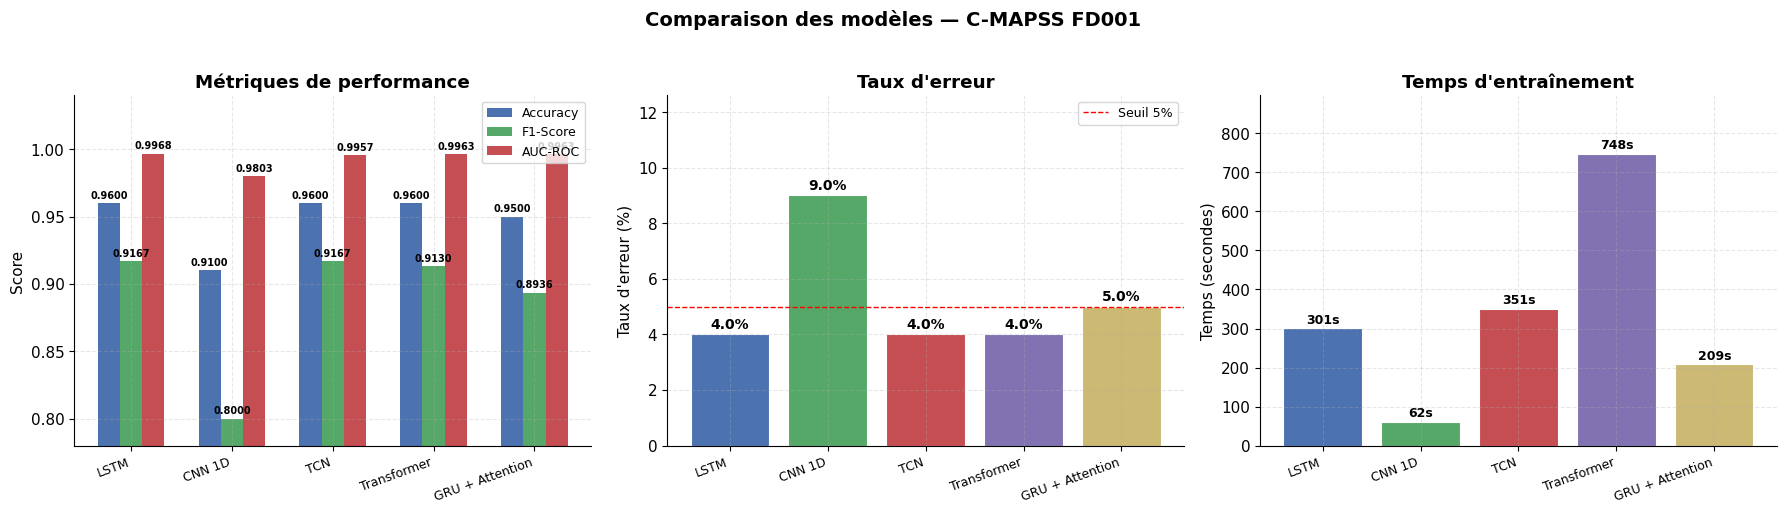

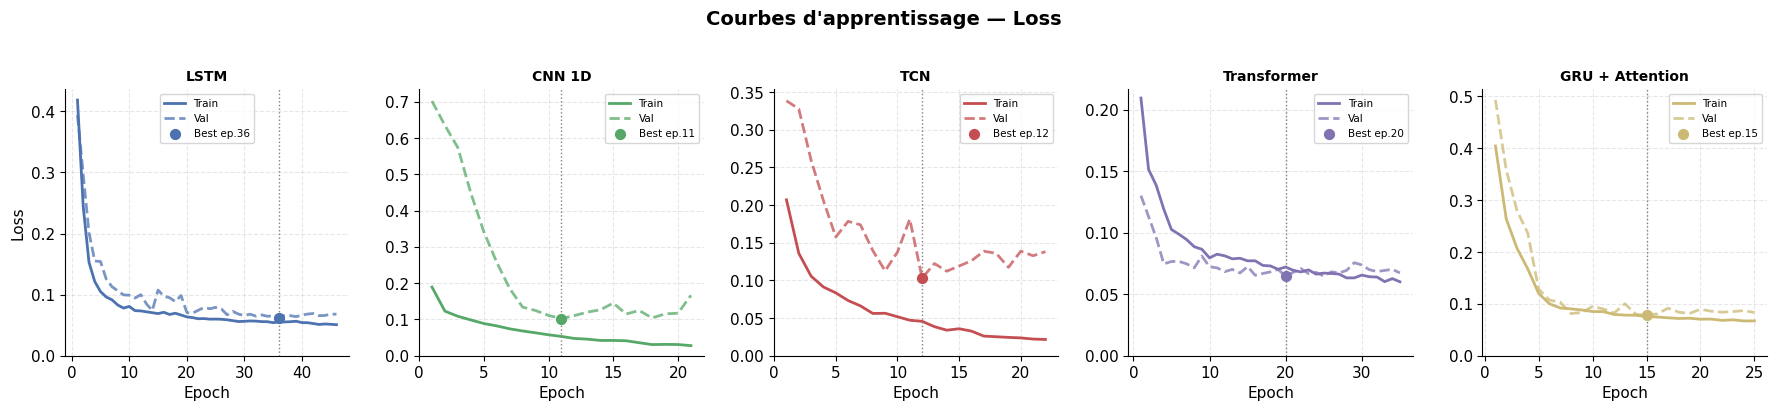


Modèle                  Accuracy        F1       AUC   Erreur    Temps
--------------------------------------------------------------------
LSTM                      0.9600    0.9167    0.9968     4.0%   301.1s ★
CNN 1D                    0.9100    0.8000    0.9803     9.0%    61.7s
TCN                       0.9600    0.9167    0.9957     4.0%   351.1s
Transformer               0.9600    0.9130    0.9963     4.0%   748.0s
GRU + Attention           0.9500    0.8936    0.9963     5.0%   208.9s


In [14]:
# ============================================================
# CELLULE 6 — COMPARAISON DES MODÈLES
# ============================================================
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# ── Noms exacts comme dans votre dictionnaire results
MODEL_NAMES = ['LSTM', 'CNN 1D', 'TCN', 'Transformer', 'GRU + Attention']
COLORS      = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

# ── Lecture directe depuis results et training_times
accuracy   = [results[m]['accuracy']              for m in MODEL_NAMES]
f1         = [results[m]['f1']                    for m in MODEL_NAMES]
auc        = [results[m]['auc']                   for m in MODEL_NAMES]
error_rate = [(1 - results[m]['accuracy']) * 100  for m in MODEL_NAMES]
train_time = [training_times[m]                   for m in MODEL_NAMES]

x = np.arange(len(MODEL_NAMES))
w = 0.22

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.size':         11,
})

# ── FIGURE 1 : Métriques + Erreur + Temps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparaison des modèles — C-MAPSS FD001',
             fontsize=14, fontweight='bold', y=1.02)

ax = axes[0]
b1 = ax.bar(x - w, accuracy, width=w, color='#4C72B0', label='Accuracy')
b2 = ax.bar(x,     f1,       width=w, color='#55A868', label='F1-Score')
b3 = ax.bar(x + w, auc,      width=w, color='#C44E52', label='AUC-ROC')
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f'{h:.4f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.78, 1.04)
ax.set_title('Métriques de performance', fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=9)

ax = axes[1]
bars = ax.bar(MODEL_NAMES, error_rate, color=COLORS, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, error_rate):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(5, color='red', linestyle='--', linewidth=1, label='Seuil 5%')
ax.set_xticks(range(len(MODEL_NAMES)))
ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right', fontsize=9)
ax.set_ylabel("Taux d'erreur (%)")
ax.set_title("Taux d'erreur", fontweight='bold')
ax.set_ylim(0, max(error_rate) * 1.4)
ax.legend(fontsize=9)

ax = axes[2]
bars = ax.bar(MODEL_NAMES, train_time, color=COLORS, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, train_time):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(MODEL_NAMES)))
ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Temps (secondes)')
ax.set_title("Temps d'entraînement", fontweight='bold')
ax.set_ylim(0, max(train_time) * 1.2)

plt.tight_layout()
plt.show()

# ── FIGURE 2 : Courbes d'apprentissage
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(18, 4))
fig.suptitle("Courbes d'apprentissage — Loss", fontsize=14, fontweight='bold', y=1.02)

for ax, model_name, color in zip(axes, MODEL_NAMES, COLORS):
    h          = histories[model_name].history
    train_loss = h['loss']
    val_loss   = h['val_loss']
    epochs     = range(1, len(train_loss) + 1)
    best_ep    = int(np.argmin(val_loss)) + 1

    ax.plot(epochs, train_loss, color=color, linewidth=2, label='Train')
    ax.plot(epochs, val_loss,   color=color, linewidth=2, linestyle='--', alpha=0.75, label='Val')
    ax.axvline(best_ep, color='gray', linestyle=':', linewidth=1)
    ax.scatter([best_ep], [val_loss[best_ep - 1]], color=color, zorder=5, s=50,
               label=f'Best ep.{best_ep}')
    ax.set_title(model_name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss' if model_name == MODEL_NAMES[0] else '')
    ax.legend(fontsize=7.5)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# ── Tableau récap
print("\n" + "="*68)
print(f"{'Modèle':<22} {'Accuracy':>9} {'F1':>9} {'AUC':>9} {'Erreur':>8} {'Temps':>8}")
print("-"*68)
for i, m in enumerate(MODEL_NAMES):
    flag = " ★" if auc[i] == max(auc) else ""
    print(f"{m:<22} {accuracy[i]:>9.4f} {f1[i]:>9.4f} {auc[i]:>9.4f}"
          f" {error_rate[i]:>7.1f}% {train_time[i]:>7.1f}s{flag}")
print("="*68)

---
## Cellule 7 : Interface Graphique Interactive de Test

In [15]:
# ============================================================
# CELLULE 7 — INTERFACE DE DIAGNOSTIC MOTEUR
# Intuitive pour novice + mode expert pour ingénieurs
# ============================================================

import gradio as gr
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io, base64

# ── Modèles déjà chargés dans les cellules précédentes
MODELS = {
    'LSTM':             lstm_model,
    'CNN 1D':           cnn_model,
    'TCN':              tcn_model,
    'Transformer':      transformer_model,
    'GRU + Attention':  gru_model,
}

MODEL_COLORS = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']

# ============================================================
# PRÉDICTION
# ============================================================

def predict(features_dict):
    x = np.array([features_dict[c] for c in FEATURE_COLS], dtype=np.float32)
    x = np.tile(x, (SEQ_LEN, 1)).reshape(1, SEQ_LEN, N_FEATURES)
    preds = {}
    for name, model in MODELS.items():
        try:
            preds[name] = float(model.predict(x, verbose=0)[0][0])
        except:
            preds[name] = 0.0
    return preds


def questions_to_features(age_pct, temp_pct, vib_pct, pres_pct, load_pct):
    """Convertit les réponses simples en vecteur de features normalisées."""
    f = {}
    for c in FEATURE_COLS:
        base  = age_pct*0.35 + temp_pct*0.2 + vib_pct*0.25 + pres_pct*0.1 + load_pct*0.1
        noise = np.random.normal(0, 0.015)
        f[c]  = float(np.clip(base + noise, 0, 1))
    return f


def expert_to_features(sensor_values: list):
    """Prend directement les valeurs normalisées de chaque capteur."""
    return {c: float(v) for c, v in zip(FEATURE_COLS, sensor_values)}

# ============================================================
# GRAPHIQUE RÉSULTAT
# ============================================================

def make_result_figure(preds: dict) -> plt.Figure:
    names  = list(preds.keys())
    vals   = list(preds.values())
    fusion = np.mean(vals)

    colors = ['#e63946' if v > 0.7 else '#f4a261' if v > 0.4 else '#2a9d8f'
              for v in vals]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4),
                                    gridspec_kw={'width_ratios': [2, 1]})
    fig.patch.set_facecolor('#0f172a')
    for ax in [ax1, ax2]:
        ax.set_facecolor('#1e293b')
        ax.tick_params(colors='white')
        ax.spines[:].set_color('#334155')

    # ── Barres scores par modèle
    bars = ax1.bar(names, vals, color=colors, edgecolor='#0f172a', linewidth=1.2, width=0.55)
    ax1.axhline(0.7, color='#e63946', linestyle='--', linewidth=1, alpha=0.7, label='Seuil critique (0.70)')
    ax1.axhline(0.4, color='#f4a261', linestyle='--', linewidth=1, alpha=0.7, label='Seuil modéré (0.40)')
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', color='white', fontsize=10, fontweight='bold')
    ax1.set_ylim(0, 1.15)
    ax1.set_title('Score de risque par modèle', color='white', fontsize=11, fontweight='bold', pad=10)
    ax1.set_ylabel('Probabilité d\'anomalie', color='white')
    ax1.legend(fontsize=8, facecolor='#1e293b', labelcolor='white', loc='upper right')
    ax1.set_xticklabels(names, rotation=15, ha='right', color='white', fontsize=9)

    # ── Donut fusion
    fus_clr = '#e63946' if fusion > 0.7 else '#f4a261' if fusion > 0.4 else '#2a9d8f'
    ax2.pie([fusion, 1 - fusion],
            colors=[fus_clr, '#334155'],
            startangle=90,
            wedgeprops=dict(width=0.45, edgecolor='#0f172a', linewidth=2))
    ax2.text(0,  0.08, f'{fusion:.0%}', ha='center', va='center',
             fontsize=26, fontweight='bold', color=fus_clr)
    ax2.text(0, -0.25, 'Score global', ha='center', fontsize=9, color='#94a3b8')
    ax2.set_title('Fusion des modèles', color='white', fontsize=11, fontweight='bold', pad=10)

    plt.tight_layout()
    return fig


def status_md(preds: dict) -> str:
    fusion = np.mean(list(preds.values()))
    if fusion > 0.7:
        icon, label, msg, color = "🔴", "RISQUE ÉLEVÉ", (
            "**Arrêt recommandé.** Le moteur présente des signes avancés de dégradation.\n\n"
            "→ Planifier une inspection complète immédiatement.\n"
            "→ Ne pas dépasser 24h sans intervention."
        ), "#ef4444"
    elif fusion > 0.4:
        icon, label, msg, color = "🟠", "RISQUE MODÉRÉ", (
            "**Surveillance renforcée nécessaire.** Des anomalies commencent à apparaître.\n\n"
            "→ Augmenter la fréquence de surveillance.\n"
            "→ Planifier une maintenance préventive sous 2 semaines."
        ), "#f97316"
    else:
        icon, label, msg, color = "🟢", "ÉTAT NORMAL", (
            "**Le moteur fonctionne normalement.** Aucune anomalie détectée.\n\n"
            "→ Continuer la surveillance périodique habituelle."
        ), "#22c55e"

    detail = "\n".join([f"- **{m}** : {v:.1%}" for m, v in preds.items()])
    return f"""
## {icon} {label}

{msg}

---
### Détail par modèle
{detail}

---
*Score de fusion (moyenne) : **{fusion:.1%}***
"""

# ============================================================
# LOGIQUE DES DEUX MODES
# ============================================================

def run_simple(age_q, temp_q, vib_q, pres_q, load_q):
    """Mode novice : questions en langage naturel avec sliders 0→100%."""
    features = questions_to_features(
        age_q/100, temp_q/100, vib_q/100, pres_q/100, load_q/100
    )
    preds = predict(features)
    return make_result_figure(preds), status_md(preds)


def run_expert(*sensor_vals):
    """Mode expert : valeurs normalisées directes par capteur."""
    features = expert_to_features(list(sensor_vals))
    preds    = predict(features)
    return make_result_figure(preds), status_md(preds)

# ============================================================
# INTERFACE GRADIO
# ============================================================

css = """
.gradio-container { background: #0f172a !important; }
.tab-nav button { color: white !important; background: #1e293b !important; border-radius: 8px !important; }
.tab-nav button.selected { background: #3b82f6 !important; }
h1, h2, h3, label, .label-wrap { color: white !important; }
.block { background: #1e293b !important; border-radius: 12px !important; border: 1px solid #334155 !important; }
footer { display: none !important; }
"""

with gr.Blocks(css=css, title="Diagnostic Moteur Industriel") as demo:

    gr.HTML("""
    <div style="background:linear-gradient(135deg,#1e3a5f,#1d4ed8);
                padding:24px 28px;border-radius:14px;margin-bottom:16px">
      <h1 style="color:white;margin:0;font-size:1.5rem">
        🏭 Diagnostic de Moteur Industriel
      </h1>
      <p style="color:#93c5fd;margin:6px 0 0;font-size:0.95rem">
        Détection d'anomalies par intelligence artificielle — NASA C-MAPSS FD001
      </p>
    </div>
    """)

    with gr.Tabs():

        # ══════════════════════════════════════════════════════
        # ONGLET 1 — MODE NOVICE
        # ══════════════════════════════════════════════════════
        with gr.Tab("🟢 Mode Simple  —  Je ne suis pas expert"):

            gr.Markdown("""
> **Comment ça marche ?**
> Répondez aux 5 questions ci-dessous en déplaçant les curseurs.
> L'IA analyse ensuite l'état du moteur et vous donne un verdict clair.
""")

            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("### ⚙️ État du moteur")

                    age_sl = gr.Slider(0, 100, value=20, step=1,
                        label="🕐 Ancienneté du moteur",
                        info="0 = neuf   |   100 = très vieux / en fin de vie")

                    temp_sl = gr.Slider(0, 100, value=20, step=1,
                        label="🌡️ Niveau de température",
                        info="0 = froide (normale)   |   100 = très chaude (alarmant)")

                    vib_sl = gr.Slider(0, 100, value=10, step=1,
                        label="📳 Niveau de vibration",
                        info="0 = silencieux (normal)   |   100 = vibrations fortes (danger)")

                    pres_sl = gr.Slider(0, 100, value=20, step=1,
                        label="💨 Pression dans le moteur",
                        info="0 = basse (normale)   |   100 = très haute (anomalie)")

                    load_sl = gr.Slider(0, 100, value=20, step=1,
                        label="⚡ Charge de travail",
                        info="0 = moteur au repos   |   100 = fonctionnement à pleine charge")

                    btn_simple = gr.Button("🔍 Analyser le moteur", variant="primary", size="lg")

                    gr.Markdown("""
---
**Légende :**
- 🟢 **Normal** → Aucune action requise
- 🟠 **Modéré** → Surveillance à prévoir
- 🔴 **Critique** → Intervention urgente
""")

                with gr.Column(scale=2):
                    plot_simple  = gr.Plot(label="Résultat visuel")
                    report_simple = gr.Markdown()

            btn_simple.click(
                fn=run_simple,
                inputs=[age_sl, temp_sl, vib_sl, pres_sl, load_sl],
                outputs=[plot_simple, report_simple],
            )

            gr.Examples(
                label="💡 Exemples prêts à tester",
                examples=[
                    [10, 10,  5, 10, 15],
                    [50, 55, 45, 50, 60],
                    [85, 80, 75, 90, 85],
                ],
                inputs=[age_sl, temp_sl, vib_sl, pres_sl, load_sl],
                outputs=[plot_simple, report_simple],
                fn=run_simple,
                example_labels=["✅ Moteur neuf", "⚠️ Usure modérée", "🚨 Proche de la panne"],
            )

        # ══════════════════════════════════════════════════════
        # ONGLET 2 — MODE EXPERT
        # ══════════════════════════════════════════════════════
        with gr.Tab("🔵 Mode Expert  —  Valeurs capteurs réelles"):

            gr.Markdown("""
> **Pour ingénieurs / techniciens.**
> Entrez directement les valeurs **normalisées [0 → 1]** de chaque capteur
> (issues du preprocessing MinMaxScaler appliqué lors de l'entraînement).
""")

            with gr.Row():
                with gr.Column(scale=1):
                    gr.Markdown("### 📡 Valeurs des capteurs (normalisées 0–1)")

                    sensor_inputs = []
                    for col in FEATURE_COLS:
                        s = gr.Slider(0.0, 1.0, value=0.3, step=0.01,
                                      label=f"Capteur : {col}")
                        sensor_inputs.append(s)

                    btn_expert = gr.Button("🔍 Lancer la prédiction", variant="primary", size="lg")

                with gr.Column(scale=2):
                    plot_expert  = gr.Plot(label="Résultat visuel")
                    report_expert = gr.Markdown()

            btn_expert.click(
                fn=run_expert,
                inputs=sensor_inputs,
                outputs=[plot_expert, report_expert],
            )

    # Chargement automatique avec valeurs par défaut
    demo.load(
        fn=run_simple,
        inputs=[
            gr.State(20), gr.State(20), gr.State(10),
            gr.State(20), gr.State(20)
        ],
        outputs=[plot_simple, report_simple],
    )

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ca1f58165d857e0791.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
